<a href="https://colab.research.google.com/github/ADRAKECROWDER/AIML2013-cv/blob/main/Week3/CombinedEmbeddings_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Cell 1 Setup Models and Imports
This cell sets up the notebook by installing the text embedding package, importing the required libraries, and loading the text and image models. Both models turn inputs into fixed-length vectors that can be compared with cosine similarity.

In [ ]:
# Install the text embedding library
!pip install -q sentence-transformers

# Import array and plotting tools
import numpy as np
import matplotlib.pyplot as plt

# Import similarity and dimensionality reduction tools
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

# Import Module 2 reference methods
from sklearn.feature_extraction.text import TfidfVectorizer
from skimage.feature import hog
from skimage.color import rgb2gray
from skimage import transform

# Import TensorFlow and MobileNetV2 preprocessing
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Import utility tools
from collections import Counter, defaultdict
import json

# Import the sentence transformer model
from sentence_transformers import SentenceTransformer

# Load the text embedding model
text_model = SentenceTransformer('all-MiniLM-L6-v2')

# Load MobileNetV2 as an image feature extractor
image_model = tf.keras.applications.MobileNetV2(
    include_top=False,         # remove classifier head
    weights='imagenet',        # use ImageNet-trained weights
    pooling='avg',             # average spatial features into one vector
    input_shape=(224, 224, 3)  # expect 224x224 RGB images
)

# Print text model info
print("Text model: all-MiniLM-L6-v2")
print("Text embedding dimension: 384")

# Print image model info
print("Image model: MobileNetV2")
print("Image embedding dimension: 1280")

# Print the shared lab idea
print("Both text and images can be converted into fixed-length numeric vectors where cosine similarity measures closeness.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text model: all-MiniLM-L6-v2
Text embedding dimension: 384
Image model: MobileNetV2
Image embedding dimension: 1280
Both text and images can be converted into fixed-length numeric vectors where cosine similarity measures closeness.


### Cell 2 Load and Organize the Text Dataset
This cell loads the text dataset, stores the matching category labels, and defines the edge-case texts.



In [ ]:
# Store the category names in order
text_cat_names = ['technology', 'sports', 'cooking', 'travel']

# Define 15 technology texts
technology_texts = [
    "The software update improved battery life on my phone.",
    "The laptop uses a fast processor and solid-state drive.",
    "Cloud storage keeps my files synced across devices.",
    "The robot followed commands using its built-in sensors.",
    "Cybersecurity protects networks from attacks and data theft.",
    "The programmer fixed the bug in the mobile app.",
    "Artificial intelligence can summarize long documents quickly.",
    "A smart watch tracks sleep, steps, and heart rate.",
    "The new graphics card made the game run smoothly.",
    "Machine learning models improve with better training data.",
    "The website loads faster after the server upgrade.",
    "The drone streamed video back to the controller.",
    "A database stores customer records in organized tables.",
    "The keyboard connects through Bluetooth without any wires.",
    "Virtual reality headsets create an immersive digital space."
]

# Define 15 sports texts
sports_texts = [
    "The basketball team won after a strong fourth quarter.",
    "The striker scored twice in the soccer match.",
    "The pitcher threw a complete game for the win.",
    "The runner trained daily for the marathon.",
    "The football defense forced three turnovers.",
    "The tennis player served an ace on match point.",
    "The coach designed a new practice plan for the team.",
    "The swimmer improved her time in the freestyle event.",
    "Fans cheered as the home team hit a late goal.",
    "The referee stopped play after the hard foul.",
    "The athlete recovered quickly from a minor injury.",
    "The stadium was full for the championship game.",
    "The golfer made a long birdie putt on the final hole.",
    "The boxer stayed balanced and protected his guard.",
    "The volleyball team communicated well on defense."
]

# Define 15 cooking texts
cooking_texts = [
    "I baked chocolate chip cookies until the edges were golden.",
    "The soup simmered slowly with carrots, onions, and garlic.",
    "She chopped fresh herbs before adding them to the pasta.",
    "The chef grilled salmon with lemon and black pepper.",
    "I whisked eggs, milk, and cinnamon for the French toast.",
    "The bread dough rose for an hour in a warm kitchen.",
    "He roasted vegetables with olive oil and sea salt.",
    "The sauce thickened after a few minutes on the stove.",
    "We used a blender to make a smooth tomato puree.",
    "The recipe calls for butter, sugar, and vanilla extract.",
    "She flipped the pancake when bubbles formed on top.",
    "The rice cooker kept the rice warm until dinner.",
    "I marinated the chicken overnight for more flavor.",
    "The baker decorated the cake with fresh strawberries.",
    "We sautéed mushrooms before serving them over noodles."
]

# Define 15 travel texts
travel_texts = [
    "The hotel overlooked the beach and the ocean.",
    "We packed light for the weekend trip to the mountains.",
    "The passport was checked before boarding the flight.",
    "They explored museums and cafés in the city center.",
    "The train ride offered great views of the countryside.",
    "We booked a guided tour of the historic ruins.",
    "The map helped us find the local market quickly.",
    "She rented a car to drive along the coastal highway.",
    "The suitcase barely fit in the overhead bin.",
    "Our itinerary included hiking, food stops, and a boat ride.",
    "The travelers arrived early at the airport terminal.",
    "We stayed in a cabin near the national park.",
    "The cruise ship stopped at several islands.",
    "He exchanged currency before the international trip.",
    "The narrow streets made the old town easy to explore on foot."
]

# Combine the 60 texts in the required order
texts = technology_texts + sports_texts + cooking_texts + travel_texts

# Create the parallel category label list
text_categories = (
    ['technology'] * 15 +
    ['sports'] * 15 +
    ['cooking'] * 15 +
    ['travel'] * 15
)

# Define 5 edge-case texts
edge_texts = [
    "I cooked a robot in my simulation game.",
    "The athlete tracked workouts on a smart watch while traveling.",
    "We used a drone to film the ski competition.",
    "The chef trained like an athlete before the cooking show.",
    "The travel app recommended restaurants near the stadium."
]

# Define labels for the edge-case texts
edge_labels = [
    ['cooking', 'technology'],
    ['sports', 'technology', 'travel'],
    ['technology', 'sports'],
    ['cooking', 'sports'],
    ['travel', 'cooking', 'sports', 'technology']
]

# Print category counts
print("Category counts:")
print(Counter(text_categories))

# Print alignment check
print("Total texts:", len(texts))
print("Total categories:", len(text_categories))

Category counts:
Counter({'technology': 15, 'sports': 15, 'cooking': 15, 'travel': 15})
Total texts: 60
Total categories: 60


###Cell 2 Output
The dataset is evenly balanced across the four text categories. It gives each category the same number of examples during comparison.

### Cell 3 Generate Text Embeddings
This cell converts all 60 texts into dense embeddings and prints the shape and sample values. Each text is now represented as a 384-dimensional vector instead of raw words.


In [ ]:
# Encode all texts into dense vectors
text_embeddings = text_model.encode(texts, show_progress_bar=True)

# Print the embedding matrix shape
print("text_embeddings.shape:", text_embeddings.shape)

# Print sample values from the first embedding
print("First 10 values of text_embeddings[0]:")
print(text_embeddings[0][:10])

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

text_embeddings.shape: (60, 384)
First 10 values of text_embeddings[0]:
[-0.09689816  0.11317851  0.02423012  0.00809147  0.06758934 -0.09071385
 -0.02565228  0.07668217 -0.03258543  0.04581486]


###Cell 3 Output
The text data was successfully converted into embeddings. Each sentence is now represented as a fixed-length numeric vector that can be compared to other sentences.

### Cell 4 Build and Test Text Retrieval
This cell builds the text retrieval function and tests it on example queries. Nearby vectors in the embedding space should represent texts with similar meaning, not just similar wording.

In [ ]:
# Define a function to retrieve similar texts
def find_similar_text(query_idx, n=5):
    # Get the query embedding
    query_embedding = text_embeddings[query_idx]

    # Score the query against all text embeddings
    scores = cosine_similarity([query_embedding], text_embeddings).flatten()

    # Exclude the query itself
    scores[query_idx] = -1

    # Sort scores from highest to lowest
    ranked_indices = np.argsort(scores)[::-1]
    top_indices = ranked_indices[:n]
    top_scores = scores[top_indices]

    # Build readable outputs
    top_texts = [texts[i] for i in top_indices]
    top_categories = [text_categories[i] for i in top_indices]
    same_category = [text_categories[i] == text_categories[query_idx] for i in top_indices]

    return top_indices, top_scores, top_texts, top_categories, same_category

# Define a helper function to print results
def print_text_results(query_idx, n=5):
    # Get retrieval results
    top_indices, top_scores, top_texts, top_categories, same_category = find_similar_text(query_idx, n=n)

    # Print query info
    print("=" * 95)
    print(f"Query index: {query_idx}")
    print(f"Query category: {text_categories[query_idx]}")
    print(f"Query text: {texts[query_idx]}")
    print("-" * 95)
    print(f"{'Rank':<5}{'Idx':<5}{'Score':<10}{'Match':<8}{'Category':<12}Text")
    print("-" * 95)

    # Print each retrieved item
    for rank, idx in enumerate(top_indices, start=1):
        check = "✓" if same_category[rank - 1] else "✗"
        print(f"{rank:<5}{idx:<5}{top_scores[rank - 1]:<10.3f}{check:<8}{top_categories[rank - 1]:<12}{top_texts[rank - 1]}")

# Test on a technology text
print_text_results(0, n=5)

print()

# Test on a cooking text
print_text_results(30, n=5)

Query index: 0
Query category: technology
Query text: The software update improved battery life on my phone.
-----------------------------------------------------------------------------------------------
Rank Idx  Score     Match   Category    Text
-----------------------------------------------------------------------------------------------
1    5    0.384     ✓       technology  The programmer fixed the bug in the mobile app.
2    10   0.335     ✓       technology  The website loads faster after the server upgrade.
3    8    0.316     ✓       technology  The new graphics card made the game run smoothly.
4    9    0.264     ✓       technology  Machine learning models improve with better training data.
5    1    0.262     ✓       technology  The laptop uses a fast processor and solid-state drive.

Query index: 30
Query category: cooking
Query text: I baked chocolate chip cookies until the edges were golden.
-----------------------------------------------------------------------------

###Cell 4 Output
The text retrieval results were strong. All were correct for both example queries. The top matches stayed in the correct category, which shows the embeddings captured the general meaning of the sentences.

### Cell 4B Compare Embeddings to a TF-IDF Baseline (from rubric not lab directions)
This cell builds a TF-IDF baseline on the same text dataset and runs the same queries used in the embedding retrieval cell. TF-IDF mostly matches shared words, while embeddings can match sentences that mean similar things even when the wording is different.



In [ ]:
# Build the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the text dataset into TF-IDF vectors
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)

# Define a function to retrieve similar texts with TF-IDF
def find_similar_text_tfidf(query_idx, n=5):
    # Get the query TF-IDF vector
    query_vector = tfidf_matrix[query_idx]

    # Compute cosine similarity against all TF-IDF vectors
    scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    # Exclude the query itself
    scores[query_idx] = -1

    # Sort scores from highest to lowest
    ranked_indices = np.argsort(scores)[::-1]
    top_indices = ranked_indices[:n]
    top_scores = scores[top_indices]

    # Build readable outputs
    top_texts = [texts[i] for i in top_indices]
    top_categories = [text_categories[i] for i in top_indices]
    same_category = [text_categories[i] == text_categories[query_idx] for i in top_indices]

    return top_indices, top_scores, top_texts, top_categories, same_category

# Define a helper function to print TF-IDF results
def print_tfidf_results(query_idx, n=5):
    # Get retrieval results
    top_indices, top_scores, top_texts, top_categories, same_category = find_similar_text_tfidf(query_idx, n=n)

    # Print query info
    print("=" * 95)
    print(f"TF-IDF Query index: {query_idx}")
    print(f"Query category: {text_categories[query_idx]}")
    print(f"Query text: {texts[query_idx]}")
    print("-" * 95)
    print(f"{'Rank':<5}{'Idx':<5}{'Score':<10}{'Match':<8}{'Category':<12}Text")
    print("-" * 95)

    # Print each retrieved item
    for rank, idx in enumerate(top_indices, start=1):
        check = "✓" if same_category[rank - 1] else "✗"
        print(f"{rank:<5}{idx:<5}{top_scores[rank - 1]:<10.3f}{check:<8}{top_categories[rank - 1]:<12}{top_texts[rank - 1]}")

# Compare the same queries used in Cell 4
print_tfidf_results(0, n=5)

print()

print_tfidf_results(30, n=5)

print()

# Add one more comparison example for the rubric minimum of 3 examples
print_tfidf_results(45, n=5)

TF-IDF Query index: 0
Query category: technology
Query text: The software update improved battery life on my phone.
-----------------------------------------------------------------------------------------------
Rank Idx  Score     Match   Category    Text
-----------------------------------------------------------------------------------------------
1    22   0.142     ✗       sports      The swimmer improved her time in the freestyle event.
2    2    0.110     ✓       technology  Cloud storage keeps my files synced across devices.
3    37   0.091     ✗       cooking     The sauce thickened after a few minutes on the stove.
4    29   0.091     ✗       sports      The volleyball team communicated well on defense.
5    27   0.085     ✗       sports      The golfer made a long birdie putt on the final hole.

TF-IDF Query index: 30
Query category: cooking
Query text: I baked chocolate chip cookies until the edges were golden.
---------------------------------------------------------------

###Cell 4B Output
The TF-IDF results were weaker than the embedding results. Several top matches came from the wrong category, which shows this method did not capture meaning as well as the embeddings in this example

### Cell 5 Load and Organize the Image Dataset
This cell loads the image dataset, stores the labels and class names, and shows sample images.


images.shape: (10000, 32, 32, 3)
Number of labels: 10000
N_PER_CLASS: 1000


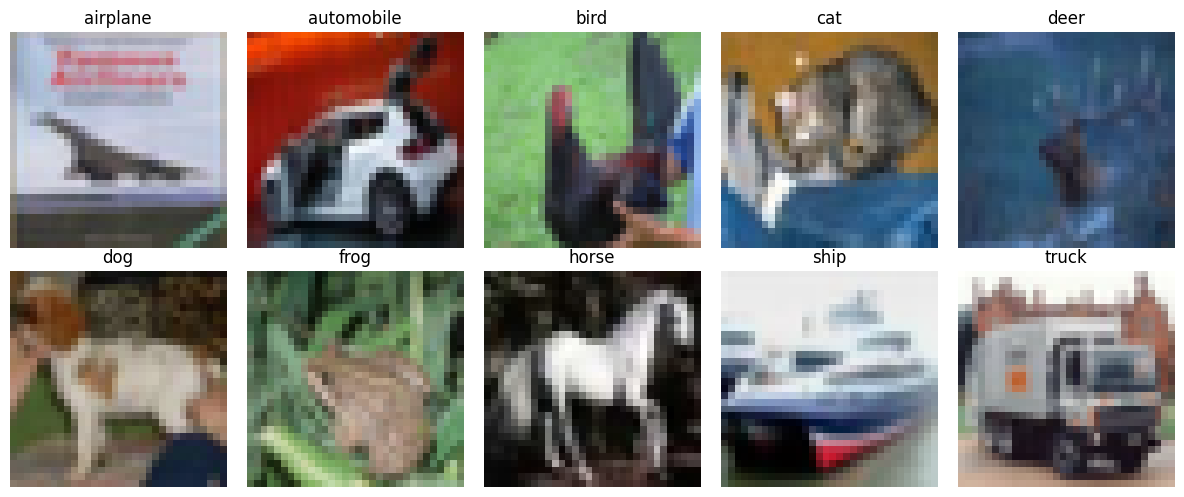

In [ ]:
# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Use the test split
images_raw = x_test
labels_raw = y_test.flatten()

# Define the CIFAR-10 class names
img_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
             'dog', 'frog', 'horse', 'ship', 'truck']

# Reorder the dataset by class so N_PER_CLASS indexing works
ordered_images = []
ordered_labels = []

for class_id in range(len(img_names)):
    # Find all images for this class
    class_indices = np.where(labels_raw == class_id)[0]

    # Add them in class order
    for idx in class_indices:
        ordered_images.append(images_raw[idx])
        ordered_labels.append(int(labels_raw[idx]))

# Store the reordered dataset
images = np.array(ordered_images)
img_labels = ordered_labels

# Set images per class for the CIFAR-10 test split
N_PER_CLASS = len(images) // len(img_names)

# Print dataset summary
print("images.shape:", images.shape)
print("Number of labels:", len(img_labels))
print("N_PER_CLASS:", N_PER_CLASS)

# Show one sample image from each class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for class_id, ax in enumerate(axes):
    sample_idx = class_id * N_PER_CLASS
    ax.imshow(images[sample_idx].astype(np.uint8))
    ax.set_title(img_names[img_labels[sample_idx]])
    ax.axis('off')

plt.tight_layout()
plt.show()

###Cell 5 Output
The CIFAR-10 test images loaded correctly, and one sample image from each class was displayed. This confirms the dataset was organized properly before creating image embeddings.

### Cell 6 Extract Image Embeddings
This cell resizes the images, preprocesses them for MobileNetV2, and extracts image embeddings. Each image is now represented as a 1,280-dimensional feature vector instead of raw pixels.





In [ ]:
# Set a batch size that fits in Colab RAM
BATCH_SIZE = 64

# Create a list to hold embedding batches
embedding_batches = []

# Process images in small batches
for start in range(0, len(images), BATCH_SIZE):
    end = start + BATCH_SIZE
    image_batch = images[start:end].astype(np.float32)

    # Scale up if values are in 0 to 1 range
    if image_batch.max() <= 1.0:
        image_batch = image_batch * 255.0

    # Resize the batch to 224x224
    image_batch = tf.image.resize(image_batch, (224, 224)).numpy()

    # Apply MobileNetV2 preprocessing
    image_batch = preprocess_input(image_batch)

    # Extract embeddings for this batch
    batch_embeddings = image_model.predict(image_batch, verbose=0)

    # Save this batch of embeddings
    embedding_batches.append(batch_embeddings)

# Stack all embedding batches together
image_embeddings = np.vstack(embedding_batches)

# Print the embedding matrix shape
print("image_embeddings.shape:", image_embeddings.shape)

# Print sample values from the first embedding
print("First 10 values of image_embeddings[0]:")
print(image_embeddings[0][:10])

# Compute and print sparsity
zero_percent = (image_embeddings == 0).sum() / image_embeddings.size * 100
print(f"Percentage of exact zeros: {zero_percent:.2f}%")

image_embeddings.shape: (10000, 1280)
First 10 values of image_embeddings[0]:
[0.1345912  0.18611932 0.         0.         0.1383545  0.02337399
 0.313694   0.31241015 0.44407293 0.        ]
Percentage of exact zeros: 21.33%


###Cell 6 Output
The images were successfully converted into embeddings. This means each image is now stored as a numeric vector that can be compared to other images for similarity.

### Cell 7 Build and Test Image Retrieval
This cell builds the image retrieval function and tests it on example images. Image similarity is based on learned visual features, so the model may group images by visual structure more than exact class labels.




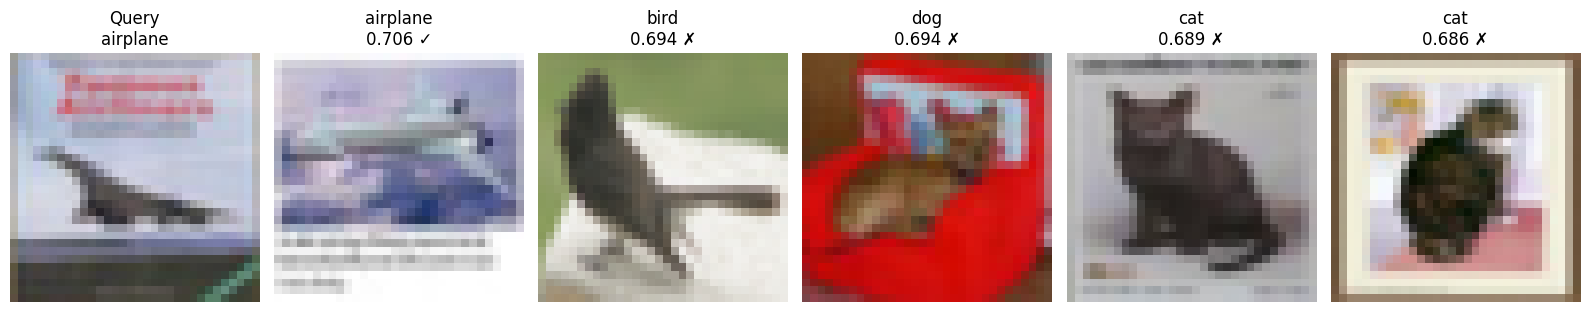

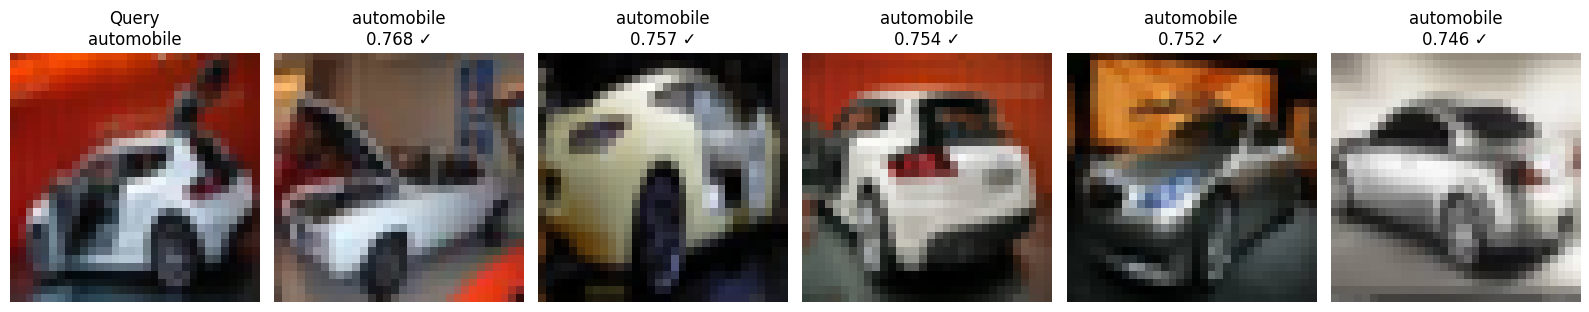

In [ ]:
# Define a function to retrieve similar images
def find_similar_image(query_idx, n=5):
    # Get the query embedding
    query_embedding = image_embeddings[query_idx]

    # Score the query against all image embeddings
    scores = cosine_similarity([query_embedding], image_embeddings).flatten()

    # Exclude the query itself
    scores[query_idx] = -1

    # Sort scores from highest to lowest
    ranked_indices = np.argsort(scores)[::-1]
    top_indices = ranked_indices[:n]
    top_scores = scores[top_indices]

    return top_indices, top_scores

# Define a helper function to show image results
def show_image_results(query_idx, n=5):
    # Get retrieval results
    top_indices, top_scores = find_similar_image(query_idx, n=n)
    query_label = img_labels[query_idx]

    # Create the display figure
    fig, axes = plt.subplots(1, n + 1, figsize=(16, 3.5))

    # Show the query image
    axes[0].imshow(images[query_idx].astype(np.uint8))
    axes[0].set_title(f"Query\n{img_names[query_label]}")
    axes[0].axis('off')

    # Show the top matches
    for ax, idx, score in zip(axes[1:], top_indices, top_scores):
        match_label = img_labels[idx]
        mark = "✓" if match_label == query_label else "✗"
        ax.imshow(images[idx].astype(np.uint8))
        ax.set_title(f"{img_names[match_label]}\n{score:.3f} {mark}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Test on the first image
show_image_results(0, n=5)

# Test on the first image of the second class
show_image_results(N_PER_CLASS, n=5)

###Cell 7 Output
For the airplane query, only one of the five retrieved images was also labeled airplane. The other results came from different classes, which shows that the model was matching based on learned visual features. The automobile query had all 5 correct matches.

### Cell 8 Compare Text and Image Embedding Spaces
This cell compares the text and image embedding spaces using dimension, value range, sparsity, intra-class similarity, inter-class similarity, and separation gap. Both spaces can organize meaning, even though they represent different types of data and use different dimensions.




In [ ]:
# Define a helper function to compute embedding space statistics
def compute_space_stats(embeddings, labels):
    # Compute the full cosine similarity matrix
    sim_matrix = cosine_similarity(embeddings, embeddings)

    # Convert labels to a NumPy array
    labels = np.array(labels)

    # Build masks for same-class and different-class pairs
    same_label = labels[:, None] == labels[None, :]
    different_label = labels[:, None] != labels[None, :]
    not_diagonal = ~np.eye(len(labels), dtype=bool)

    # Separate intra-class and inter-class pairs
    intra_class_mask = same_label & not_diagonal
    inter_class_mask = different_label

    # Compute the required metrics
    dim = embeddings.shape[1]
    value_min = np.min(embeddings)
    value_max = np.max(embeddings)
    sparsity = (embeddings == 0).sum() / embeddings.size * 100
    mean_intra = sim_matrix[intra_class_mask].mean()
    mean_inter = sim_matrix[inter_class_mask].mean()
    separation_gap = mean_intra - mean_inter

    return {
        "Dimension": dim,
        "Value min": value_min,
        "Value max": value_max,
        "Sparsity %": sparsity,
        "Mean intra-class cosine": mean_intra,
        "Mean inter-class cosine": mean_inter,
        "Separation gap": separation_gap
    }

# Compute statistics for text embeddings
text_stats = compute_space_stats(text_embeddings, text_categories)

# Compute statistics for image embeddings
image_stats = compute_space_stats(image_embeddings, img_labels)

# Print the comparison table
print(f"{'Metric':<28}{'Text Embeddings':<20}{'Image Embeddings':<20}")
print("-" * 68)

for metric in text_stats:
    text_value = text_stats[metric]
    image_value = image_stats[metric]

    if isinstance(text_value, (float, np.floating)):
        print(f"{metric:<28}{text_value:<20.4f}{image_value:<20.4f}")
    else:
        print(f"{metric:<28}{text_value:<20}{image_value:<20}")

Metric                      Text Embeddings     Image Embeddings    
--------------------------------------------------------------------
Dimension                   384                 1280                
Value min                   -0.2019             0.0000              
Value max                   0.2209              5.9638              
Sparsity %                  0.0000              21.3298             
Mean intra-class cosine     0.2002              0.6086              
Mean inter-class cosine     0.0474              0.5406              
Separation gap              0.1528              0.0680              


###Cell 8 Output
The text embeddings showed clearer separation between categories than the image embeddings. The separation gap was 0.1528 for the text embeddings, compared with 0.0680 for image embeddings, which means the text categories were more clearly separated in this result.

### Cell 8 Markdown
This result shows that a larger number of dimensions does not automatically mean a representation is better. Both text and image embeddings were useful, even though the image vectors were larger. Images likely need more dimensions because visual data contains more detail, variation, and spatial information than short text sentences.

### Cell 9 Visualize Both Embedding Spaces with t-SNE
This cell reduces both embedding spaces to 2D with t-SNE and plots them side by side. The plot makes it easier to see where the model forms clear clusters and where classes or categories overlap.





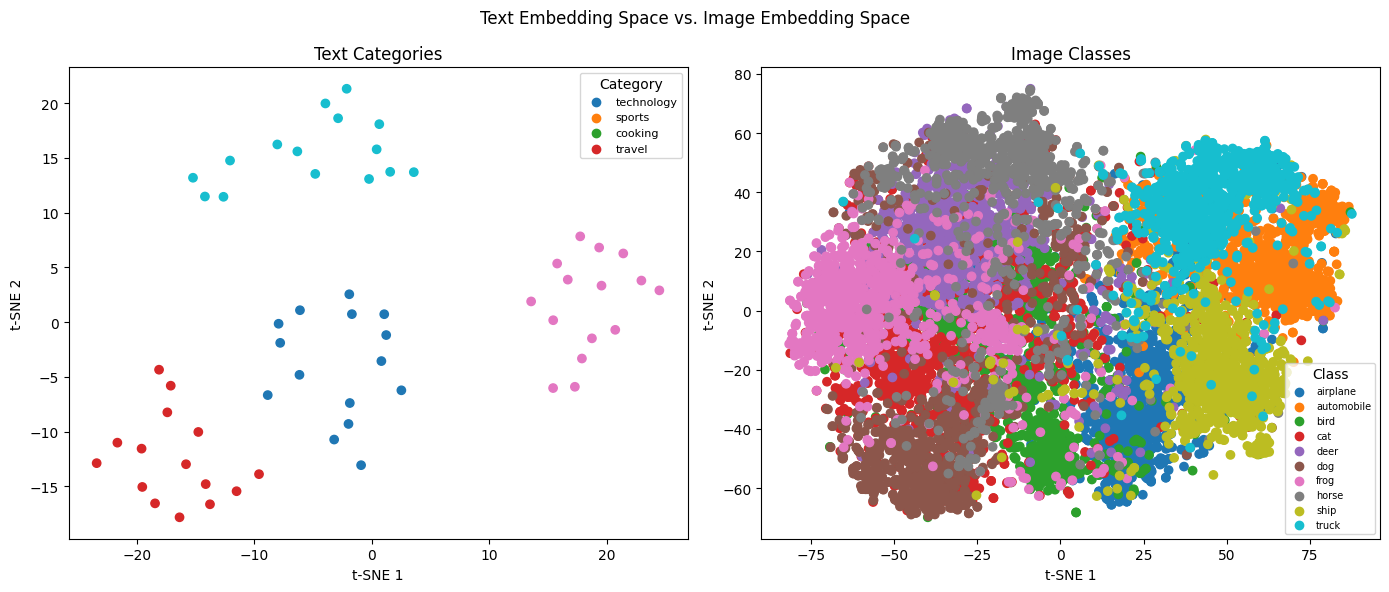

In [ ]:
# Reduce text embeddings to 2D with t-SNE
text_2d = TSNE(n_components=2, random_state=42, perplexity=10).fit_transform(text_embeddings)

# Reduce image embeddings to 2D with t-SNE
image_2d = TSNE(n_components=2, random_state=42, perplexity=15).fit_transform(image_embeddings)

# Create side-by-side plots
fig, (ax_text, ax_img) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Text Embedding Space vs. Image Embedding Space")

# Map text categories to colors
text_color_map = {name: i for i, name in enumerate(text_cat_names)}
text_colors = [text_color_map[label] for label in text_categories]

# Plot text embeddings
ax_text.scatter(text_2d[:, 0], text_2d[:, 1], c=text_colors, cmap='tab10')
ax_text.set_title("Text Categories")
ax_text.set_xlabel("t-SNE 1")
ax_text.set_ylabel("t-SNE 2")

# Add text legend
for name, idx in text_color_map.items():
    ax_text.scatter([], [], c=[plt.cm.tab10(idx)], label=name)
ax_text.legend(title="Category", fontsize=8)

# Plot image embeddings
ax_img.scatter(image_2d[:, 0], image_2d[:, 1], c=img_labels, cmap='tab10')
ax_img.set_title("Image Classes")
ax_img.set_xlabel("t-SNE 1")
ax_img.set_ylabel("t-SNE 2")

# Add image legend
for class_id, class_name in enumerate(img_names):
    ax_img.scatter([], [], c=[plt.cm.tab10(class_id)], label=class_name)
ax_img.legend(title="Class", fontsize=7, loc='best')

plt.tight_layout()
plt.show()

###Cell 9 Output
The text grouping has perfect grouping with no outliers. The Image class visual grouping is mostly correct, with clear visual clusters. Most items were near their class, while a few points fell farther way from thier class.

### Cell 9 Markdown
The text plot showed about four category groups, while the image plot showed 10 class groupings. The text categories appeared more cleanly separated. The image classes were still clearly visible, but they had more overlap and a few points farther from the main groups. This suggests the text categories were easier to separate in this dataset, while the image classes were harder to distinguish.

### Cell 10 Find and Compare Failure Cases
This cell finds the strongest wrong match in both text and image retrieval. Text errors usually come from overlapping meaning, while image errors usually come from overlapping visual structure.





No wrong text retrieval found.



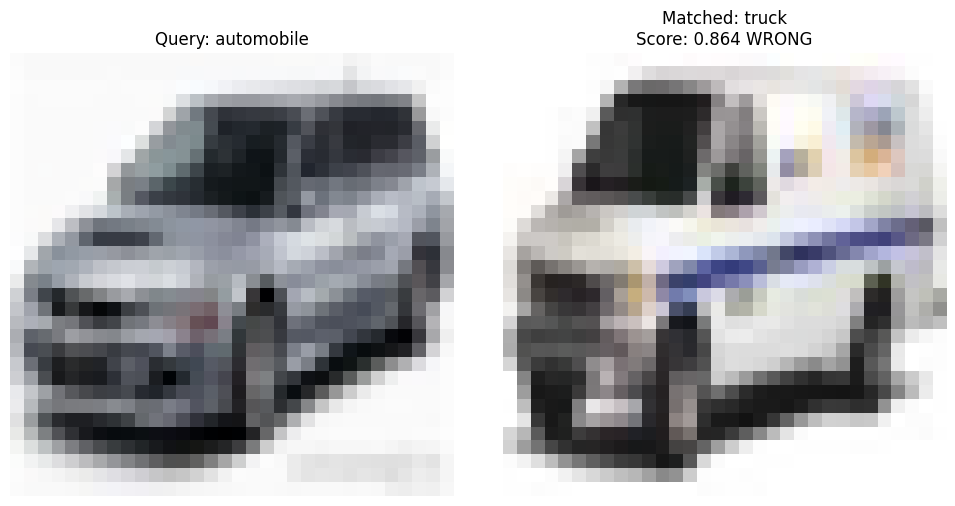

In [ ]:
# Search for the strongest wrong text match
text_failures = []

for i in range(len(texts)):
    # Get the top text match
    top_indices, top_scores, _, _, _ = find_similar_text(i, n=1)
    match_idx = top_indices[0]
    score = top_scores[0]

    # Keep only wrong-category matches
    if text_categories[match_idx] != text_categories[i]:
        text_failures.append((i, match_idx, score))

# Select the highest-scoring wrong text match
best_text_failure = max(text_failures, key=lambda x: x[2]) if text_failures else None

# Search for the strongest wrong image match
image_failures = []

for i in range(len(images)):
    # Get the top image match
    top_indices, top_scores = find_similar_image(i, n=1)
    match_idx = top_indices[0]
    score = top_scores[0]

    # Keep only wrong-class matches
    if img_labels[match_idx] != img_labels[i]:
        image_failures.append((i, match_idx, score))

# Select the highest-scoring wrong image match
best_image_failure = max(image_failures, key=lambda x: x[2]) if image_failures else None

# Print the text failure summary
if best_text_failure is not None:
    q_idx, m_idx, score = best_text_failure
    print(
        f"Text failure: {texts[q_idx][:80]}... | "
        f"Matched to: {texts[m_idx][:80]}... | "
        f"Query category: {text_categories[q_idx]} | "
        f"Matched category: {text_categories[m_idx]} | "
        f"Score: {score:.3f}"
    )
else:
    print("No wrong text retrieval found.")

print()

# Display the image failure
if best_image_failure is not None:
    q_idx, m_idx, score = best_image_failure

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Show the query image
    axes[0].imshow(images[q_idx].astype(np.uint8))
    axes[0].set_title(f"Query: {img_names[img_labels[q_idx]]}")
    axes[0].axis('off')

    # Show the wrong matched image
    axes[1].imshow(images[m_idx].astype(np.uint8))
    axes[1].set_title(f"Matched: {img_names[img_labels[m_idx]]}\nScore: {score:.3f} WRONG")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No wrong image retrieval found.")

###Cell 10 Output
No incorrect text retrieval example was found, because the text results were very consistent. For the image query it matched an automobile to a truck, and the notebook counted that as incorrect because CIFAR-10 treats automobile and truck as separate classes. I would not fully consider that match wrong because a truck is still a type of automobile.

### Cell 10 Markdown
The text model did not show a wrong match in this output, which suggests its results stayed consistent across topics. The image model confused an automobile with a truck, which is a mistake based on class labels but still a visually close match. This shows that text errors are more about meaning, while image errors are more about visual patterns like shape, edges, and overall appearance.

## Reflection Summary

This lab showed how both text and images can be converted into numeric representations and compared by similarity. In the text portion, the sentence embeddings performed well and returned matches from the correct category consistently. The results showed that the text model captured the overall meaning of the sentences. The text categories also appeared more clearly separated in the grouping results.

In the image portion, the model didnt perform as well. Only 1 of the querys were correct. It was sucessfully in identifity automobiles in Cell 7 but not successful with an airplance query. Although it was sucessfull with the automobile query in cell 7, in Cell 10 it showed an automobile matched to a truck, which the dataset counts as incorrect because those are separate class labels. The image grouping still showed more overlap than the text grouping, which suggests that the image classes in this dataset were harder to separate clearly.

Overall, this lab showed that both types of models can organize data by similarity. The text results were more clearly separated in this example. The lab also showed that text and image models rely on different kinds of patterns when they sort and retrieve information.